# **Advanced Large Language Models and Reinforcement Learning Human Feedback**

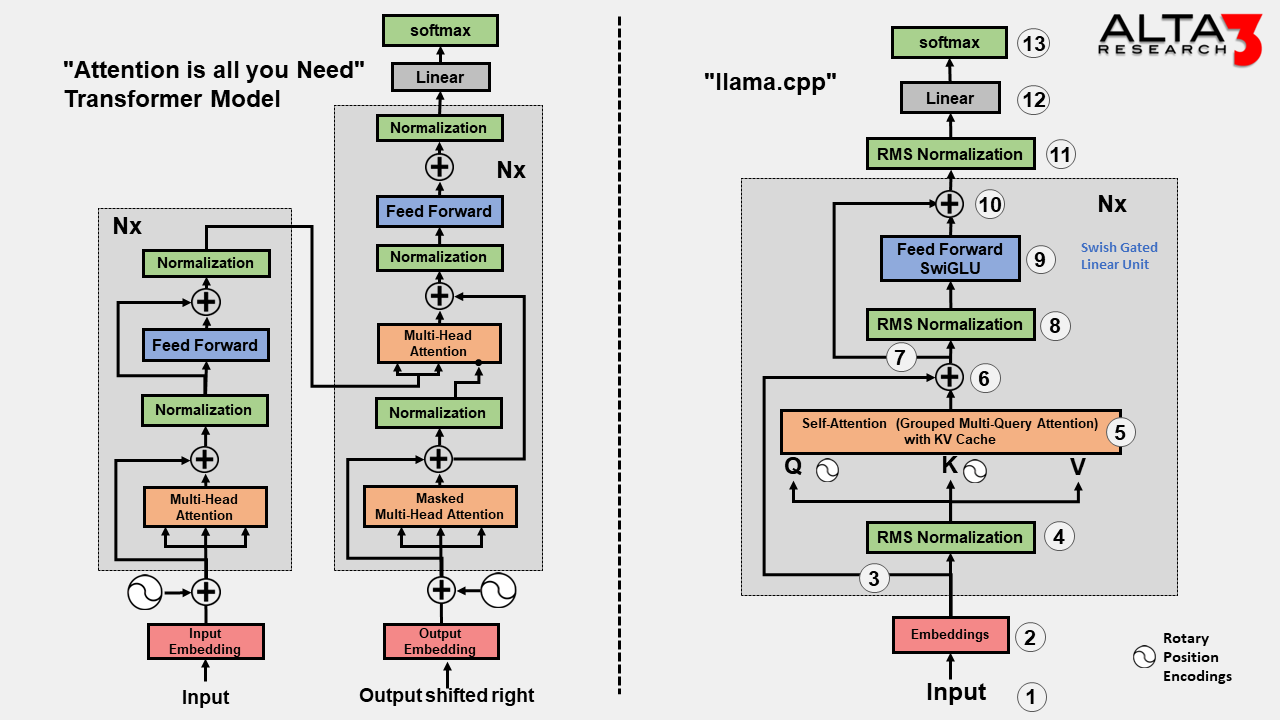

**Block 1: Import Required Libraries & Environment Setup**

In [ ]:
# ============================================================
# Block 1: Import Required Libraries & Environment Setup
# ============================================================

import os
import re
import io
import math
import json
import time
import random
import requests
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# ------------------------------------------------------------
# Device Configuration
# ------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using Device: {device}")

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# Ensure deterministic behavior for reproducible experiments
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ------------------------------------------------------------
# CUDA Debugging (Optional)
# Uncomment ONLY if debugging CUDA runtime errors.
# This slows down execution because CUDA operations become synchronous.
# ------------------------------------------------------------
# os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

print(f"Random Seed Set To: {SEED}")

Using Device: cuda
Random Seed Set To: 42


**Block 2: Create a Tiny Training Corpus**

In [ ]:
# ============================================================
# Block 2: Create a Tiny Training Corpus
# ============================================================

"""
For educational purposes, we create a very small text corpus.

A real LLaMA model is trained on trillions of tokens collected
from books, websites, research papers, and code.

Training on such massive datasets requires thousands of GPUs.

In this notebook, we use a tiny custom corpus so that students
can understand every stage of the LLaMA pipeline without requiring
large computational resources.
"""

TINY_STORY = [
    "He arrived at first light, the university tucked into the hills where the air felt new each morning.",
    "Somewhere behind the ridge a dam held the valley's quiet together, not seen, only sensed in the cool hush.",
    "The campus paths curled between pines and stone, and he walked them like lines in a notebook he was ready to fill.",
    "The bootcamp moved fast—roll calls early, lamps burning late, but the pace felt like a river he could learn to swim.",
    "Rain came some afternoons, soft on rooftops, and the whole place listened.",
    "He learned to listen too: to mentors, to friends, to the small voice that said keep going.",
    "In the cafeteria he found a table that became home, faces from distant towns turning into familiar laughter.",
    "They swapped stories over hot tea, collecting each other's courage without saying the word.",
    "When the day grew heavy, he took the upper path and breathed the tall silence of the hills.",
    "Nights were calm and wide; the sky was a slow clock and he could feel himself catching up.",
    "He kept a pocket journal—one page for questions, one for lessons, one for the tiny wins that make a week.",
    "Some mornings the fog sat low and kind, as if the world wanted to start softly for their sake.",
    "He discovered that showing up was its own kind of talent, and practice was a patient friend.",
    "Group work turned strangers into teammates, and teammates into the kind of friends who save you a seat.",
    "He learned the rhythm of effort: lean in, breathe, try again, smile anyway.",
    "On the steps outside the library, rain-damp stone cooled his palms and steadied his thoughts.",
    "He called home less to report and more to share—how the hills were teaching him to take longer breaths.",
    "Sometimes they celebrated nothing in particular, just the good tired that follows honest work.",
    "He noticed how dawn arrived earlier in his heart than on the clock, and the day met him halfway.",
    "The dam stayed hidden, yet its steadiness lived in the air, a reminder that strength can be quiet.",
    "By the final week he could measure progress in gentler ways: clearer eyes, steadier hands, kinder words.",
    "When he packed to leave, the hills felt like pages he had written on, and he promised to keep the handwriting."
]

print(f"Number of sentences: {len(TINY_STORY)}")

Number of sentences: 22


Block 3: Simple Regex Tokenizer (Educational Version)

In [ ]:
# ============================================================
# Block 3: Simple Regex Tokenizer (Educational Version)
# ============================================================

"""
This notebook uses a simple regex tokenizer so students can
understand every step of the language-model pipeline.

Real LLaMA models use a SentencePiece Byte Pair Encoding (BPE)
tokenizer with a vocabulary of approximately 32,000 subword tokens.

Example (Toy Regex Tokenizer):
    "Hello, world!"
        -> ["Hello", ",", "world", "!"]

Example (Real LLaMA Tokenizer):
    "understanding"
        -> ["▁under", "stand", "ing"]   (illustrative example)

The regex below extracts:
1. Consecutive letters and digits as one token.
2. Every punctuation/special character as its own token.
"""

WORD_RE = re.compile(
    r"[A-Za-z0-9]+|[^\sA-Za-z0-9]"
)

**Example**

In [ ]:
examples = [
    "Hello, world!",
    "bootcamp_2026",
    "AI is amazing!",
    "LLaMA-3 rocks :)"
]

for text in examples:
    print(f"\nInput : {text}")
    print("Tokens:", WORD_RE.findall(text))


Input : Hello, world!
Tokens: ['Hello', ',', 'world', '!']

Input : bootcamp_2026
Tokens: ['bootcamp', '_', '2026']

Input : AI is amazing!
Tokens: ['AI', 'is', 'amazing', '!']

Input : LLaMA-3 rocks :)
Tokens: ['LLaMA', '-', '3', 'rocks', ':', ')']


In [ ]:
# print(WORD_RE.findall("light,"))       # Expected: ['light', ',']

# print(WORD_RE.findall("fast—roll"))    # Expected: ['fast', '—', 'roll']

# print(WORD_RE.findall("valley’s"))     # Expected: ['valley', '’', 's']

# print(WORD_RE.findall("Nights; sky"))  # Expected: ['Nights', ';', 'sky']

**Block 4: Build the Training Corpus**

In [ ]:
# ============================================================
# Block 4: Build the Training Corpus
# ============================================================

def tiny_corpus_text(repeat=10, seed=42):
    """
    Creates a small training corpus for the educational LLaMA implementation.

    Steps:
    1. Copy the original stories.
    2. Shuffle them using a fixed random seed.
    3. Join them into one large text document.
    4. Repeat the document multiple times to increase the number of training tokens.

    Note:
    Repeating the corpus is ONLY for educational purposes so that the
    model has enough examples to learn during training on a CPU or a
    free Colab GPU. Real LLaMA models are trained on trillions of unique
    tokens and do not repeat the same document like this.
    """

    # Create a copy so the original dataset remains unchanged
    stories = TINY_STORY.copy()

    # Deterministic random generator (does not affect global random state)
    rng = random.Random(seed)

    # Shuffle the stories
    rng.shuffle(stories)

    # Merge all stories into one text document
    text = "\n\n".join(stories)

    # Repeat the corpus to increase the number of training tokens
    text = (text + "\n\n") * repeat

    return text

**Block 5: Word-Level Dataset**

In [ ]:
# ============================================================
# Block 5: Word-Level Dataset
# ============================================================

class WordDataset(Dataset):
    """
    Creates next-token prediction examples for training a language model.

    Pipeline:
        Raw Text
            ↓
        Tokenization
            ↓
        Vocabulary
            ↓
        Token IDs
            ↓
        Train / Validation Split
            ↓
        Sliding Windows
            ↓
        (Input, Target) Pairs
    """

    def __init__(self, split="train", ctx_len=256):

        # ----------------------------------------------------
        # Build corpus
        # ----------------------------------------------------
        text = tiny_corpus_text(repeat=100)

        # Lowercase only for this educational example.
        # Real LLaMA preserves the original casing.
        text = text.lower()

        # ----------------------------------------------------
        # Tokenize
        # ----------------------------------------------------
        tokens = WORD_RE.findall(text)

        # ----------------------------------------------------
        # Build Vocabulary
        # ----------------------------------------------------
        special_tokens = ["<unk>"]

        vocab = special_tokens + sorted(set(tokens))

        self.stoi = {token: idx for idx, token in enumerate(vocab)}
        self.itos = {idx: token for token, idx in self.stoi.items()}

        self.vocab_size = len(vocab)
        self.tokens = tokens

        # ----------------------------------------------------
        # Convert Tokens to IDs
        # ----------------------------------------------------
        ids = torch.tensor(
            [self.stoi.get(token, self.stoi["<unk>"]) for token in tokens],
            dtype=torch.long,
        )

        # ----------------------------------------------------
        # Train / Validation Split
        # ----------------------------------------------------
        split_idx = int(0.8 * len(ids))

        if split == "train":
            self.data = ids[:split_idx]
        else:
            self.data = ids[split_idx:]

        self.ctx_len = ctx_len

    def __len__(self):
        return max(0, len(self.data) - self.ctx_len)

    def __getitem__(self, idx):
        """
        Example

        Input:
            I love deep learning

        Target:
              love deep learning models
        """

        x = self.data[idx : idx + self.ctx_len]

        y = self.data[idx + 1 : idx + self.ctx_len + 1]

        return x, y

**Block 6: Create DataLoaders**

In [ ]:
# ============================================================
# Block 6: Create DataLoaders
# ============================================================

def make_loaders(ctx_len, batch_size, num_workers=2):
    """
    Creates training and validation DataLoaders.

    Returns:
        train_loader
        val_loader
        vocab_size
        (stoi, itos)
    """

    # --------------------------------------------------------
    # Build datasets
    # --------------------------------------------------------
    train_ds = WordDataset(split="train", ctx_len=ctx_len)
    val_ds = WordDataset(split="val", ctx_len=ctx_len)

    vocab_size = train_ds.vocab_size

    # --------------------------------------------------------
    # Training DataLoader
    # --------------------------------------------------------
    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        drop_last=True,
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available(),
        persistent_workers=(num_workers > 0),
    )

    # --------------------------------------------------------
    # Validation DataLoader
    # --------------------------------------------------------
    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        drop_last=True,
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available(),
        persistent_workers=(num_workers > 0),
    )

    return (
        train_loader,
        val_loader,
        vocab_size,
        (train_ds.stoi, train_ds.itos),
    )

In [ ]:
# a, b = zip(*[("A0", "B0"), ("A1", "B1"), ("A2", "B2")])

# print(a)
# print(b)

**Block 7: Model Configuration (Hyperparameters)**

In [ ]:
# ============================================================
# Block 7: Model Configuration (Hyperparameters)
# ============================================================

CFG = {

    # --------------------------------------------------------
    # Dataset / Training
    # --------------------------------------------------------
    "ctx_len": 256,           # Maximum context window
    "batch_size": 4,          # Training batch size
    "steps": 100,             # Number of optimization steps
    "lr": 3e-4,               # Learning rate

    # --------------------------------------------------------
    # Precision
    # --------------------------------------------------------
    "amp": False,             # Automatic Mixed Precision

    # --------------------------------------------------------
    # TinyLLaMA Architecture
    # --------------------------------------------------------
    "embed_dim": 384,         # Embedding / hidden dimension
    "num_layers": 4,          # Number of Transformer blocks
    "num_heads": 8,           # Query attention heads
    "num_kv_heads": 2,        # KV heads for Grouped Query Attention

    # --------------------------------------------------------
    # Rotary Position Embeddings (RoPE)
    # --------------------------------------------------------
    "rope_theta": 10000.0,

    # --------------------------------------------------------
    # Visualization
    # --------------------------------------------------------
    "store_attn": False,
}

# ------------------------------------------------------------
# Derived Hyperparameters
# ------------------------------------------------------------

CFG["head_dim"] = CFG["embed_dim"] // CFG["num_heads"]

assert (
    CFG["embed_dim"] % CFG["num_heads"] == 0
), "Embedding dimension must be divisible by the number of attention heads."

print("=" * 60)
print("TinyLLaMA Configuration Loaded")
print("=" * 60)

for key, value in CFG.items():
    print(f"{key:15s}: {value}")

TinyLLaMA Configuration Loaded
ctx_len        : 256
batch_size     : 4
steps          : 100
lr             : 0.0003
amp            : False
embed_dim      : 384
num_layers     : 4
num_heads      : 8
num_kv_heads   : 2
rope_theta     : 10000.0
store_attn     : False
head_dim       : 48


**Block 8: Create Training and Validation DataLoaders**

In [ ]:
# ============================================================
# Block 8: Create Training and Validation DataLoaders
# ============================================================

train_loader, validation_loader, vocab_size, (STOI, ITOS) = make_loaders(
    ctx_len=CFG["ctx_len"],
    batch_size=CFG["batch_size"],
)

print("Data preparation completed.")
print(f"Vocabulary Size : {vocab_size}")
print(f"Training Batches: {len(train_loader)}")
print(f"Validation Batches: {len(validation_loader)}")

Data preparation completed.
Vocabulary Size : 253
Training Batches: 9036
Validation Batches: 2211


In [ ]:
# (n, m) = (0, 5)

# STOI -> String to Index (Vocabulary we used to call it)
# print(f'\nAt index {n} to {m - 1} in STOI: {dict(list(STOI.items())[:5])}\n')                         # First 5 elements in the vocabulary

# ITOS -> Index to String (Reverse Dictionary of the STOI)
# print(f'\nAt index {n} to {m - 1} in  ITOS: {dict(list(ITOS.items())[:5])}\n')                        # First 5 elements in the index-vocabulary


In [ ]:
# len(train_loader)
# next(iter(train_loader))

# len(validation_loader)
# next(iter(validation_loader))

**Block 9: RMSNorm**

In [ ]:
# ============================================================
# Block 9: RMSNorm
# ============================================================

class RMSNorm(nn.Module):
    """
    Root Mean Square Layer Normalization.

    Used in the LLaMA architecture instead of LayerNorm.

    RMSNorm scales the input using its root mean square (RMS)
    without subtracting the mean.
    """

    def __init__(self, d, eps=1e-6):
        super().__init__()

        self.weight = nn.Parameter(torch.ones(d))
        self.eps = eps

    def forward(self, x):
        # Compute Root Mean Square
        rms = torch.rsqrt(
            x.pow(2).mean(dim=-1, keepdim=True) + self.eps
        )

        # Scale normalized activations
        return x * rms * self.weight

**Block 10: SwiGLU Activation**

In [ ]:
# ============================================================
# Block 10: SwiGLU Activation
# ============================================================

def swiglu(x):
    """
    SwiGLU activation used in the LLaMA Feed-Forward Network.

    Input shape:
        (..., 2 * hidden_dim)

    Steps:
        1. Split tensor into two equal parts.
        2. Apply SiLU activation to the first half.
        3. Multiply element-wise with the second half.

    Output shape:
        (..., hidden_dim)
    """

    gate, value = x.chunk(2, dim=-1)

    return F.silu(gate) * value

**Block 11: Rotary Positional Embedding (RoPE)**

In [ ]:
# ============================================================
# Block 11: Rotary Positional Embedding (RoPE)
# Compute Inverse Frequencies
# ============================================================

def rope_inv_freq(head_dim, base=10000.0, device="cpu"):
    """
    Computes the inverse frequencies used by Rotary Positional Embeddings.

    Parameters
    ----------
    head_dim : int
        Dimension of one attention head.

    base : float
        RoPE base frequency (10000 for LLaMA).

    device : str or torch.device
        Device where the tensor will be created.

    Returns
    -------
    Tensor of shape (head_dim // 2,)
        Inverse frequencies used to generate
        sinusoidal rotation angles.
    """

    half_dim = head_dim // 2

    inv_freq = 1.0 / (
        base ** (
            torch.arange(
                half_dim,
                device=device,
                dtype=torch.float32,
            ) / half_dim
        )
    )

    return inv_freq

In [ ]:
# ============================================================
# Block 12: Apply Rotary Positional Embeddings (RoPE)
# ============================================================

def rope_apply(x, cos, sin):
    """
    Applies Rotary Positional Embeddings (RoPE).

    Parameters
    ----------
    x : Tensor
        Shape: [Batch, Heads, Sequence Length, Head Dimension]

    cos, sin : Tensor
        Cosine and sine rotation values.

    Returns
    -------
    Tensor with the same shape as x after rotating every
    even/odd dimension pair.
    """

    # Split into even and odd dimensions
    even = x[..., ::2]
    odd = x[..., 1::2]

    # Apply 2D rotation
    rotated = torch.stack(
        (
            even * cos - odd * sin,
            even * sin + odd * cos,
        ),
        dim=-1,
    )

    # Restore original tensor shape
    return rotated.flatten(-2)

**Block 13: Grouped Query Attention (GQA) with RoPE**

In [ ]:
# ============================================================
# Block 13: Grouped Query Attention (GQA) with RoPE
# ============================================================

class AttentionGQA(nn.Module):
    """
    Grouped Query Attention (GQA) used in LLaMA.

    Pipeline:
        Input
          │
          ▼
      Linear Projections
      (Q, K, V)
          │
          ▼
      Apply RoPE to Q & K
          │
          ▼
      Grouped Query Attention
          │
          ▼
      Causal Mask
          │
          ▼
      Softmax
          │
          ▼
      Weighted Sum
          │
          ▼
      Output Projection
    """

    def __init__(
        self,
        d_model,
        n_heads,
        n_kv_heads,
        ctx_len,
        rope_theta=10000.0,
        store_attn=False,
    ):
        super().__init__()

        assert d_model % n_heads == 0, "d_model must be divisible by n_heads."
        assert n_heads % n_kv_heads == 0, "n_heads must be divisible by n_kv_heads."

        self.h = n_heads
        self.hk = n_kv_heads
        self.dh = d_model // n_heads

        # ----------------------------------------------------
        # Linear Projections
        # ----------------------------------------------------
        self.Wq = nn.Linear(d_model, d_model, bias=False)
        self.Wk = nn.Linear(d_model, self.hk * self.dh, bias=False)
        self.Wv = nn.Linear(d_model, self.hk * self.dh, bias=False)
        self.Wo = nn.Linear(d_model, d_model, bias=False)

        # ----------------------------------------------------
        # Rotary Positional Embedding Frequencies
        # ----------------------------------------------------
        self.register_buffer(
            "inv_freq",
            rope_inv_freq(self.dh, base=rope_theta),
        )

        # ----------------------------------------------------
        # Pre-computed Causal Mask
        # ----------------------------------------------------
        mask = torch.triu(
            torch.ones(ctx_len, ctx_len, dtype=torch.bool),
            diagonal=1,
        )

        self.register_buffer("causal_mask", mask)

        self.store_attn = store_attn
        self.last_attn = None

    def forward(self, x):

        # ----------------------------------------------------
        # Input Shape
        # x : [Batch, Sequence Length, d_model]
        # ----------------------------------------------------
        B, T, C = x.shape

        # ----------------------------------------------------
        # Compute Query, Key and Value
        # ----------------------------------------------------
        q = (
            self.Wq(x)
            .view(B, T, self.h, self.dh)
            .transpose(1, 2)
        )  # [B,H,T,D]

        k = (
            self.Wk(x)
            .view(B, T, self.hk, self.dh)
            .transpose(1, 2)
        )  # [B,HK,T,D]

        v = (
            self.Wv(x)
            .view(B, T, self.hk, self.dh)
            .transpose(1, 2)
        )  # [B,HK,T,D]

        # ----------------------------------------------------
        # Expand K/V Heads (Grouped Query Attention)
        # ----------------------------------------------------
        repeat_factor = self.h // self.hk

        k = k.repeat_interleave(repeat_factor, dim=1)
        v = v.repeat_interleave(repeat_factor, dim=1)

        # ----------------------------------------------------
        # Rotary Positional Embeddings
        # ----------------------------------------------------
        positions = (
            torch.arange(T, device=x.device)[:, None]
            * self.inv_freq[None, :]
        )

        cos = positions.cos()[None, None, :, :]
        sin = positions.sin()[None, None, :, :]

        q = rope_apply(q, cos, sin)
        k = rope_apply(k, cos, sin)

        # ----------------------------------------------------
        # Scaled Dot-Product Attention
        # ----------------------------------------------------
        att = (q @ k.transpose(-2, -1)) / math.sqrt(self.dh)

        att = att.masked_fill(
            self.causal_mask[:T, :T],
            float("-inf"),
        )

        att = F.softmax(att, dim=-1)

        if self.store_attn:
            self.last_attn = att.detach()

        # ----------------------------------------------------
        # Weighted Sum of Values
        # ----------------------------------------------------
        out = att @ v

        out = (
            out.transpose(1, 2)
            .contiguous()
            .view(B, T, C)
        )

        # ----------------------------------------------------
        # Final Output Projection
        # ----------------------------------------------------
        out = self.Wo(out)

        return out

**Block 14: Feed-Forward Network (SwiGLU)**

In [ ]:
# ============================================================
# Block 14: Feed-Forward Network (SwiGLU)
# ============================================================

class MLP_SwiGLU(nn.Module):
    """
    Feed-Forward Network used in LLaMA.

    Pipeline:
        Input
          │
          ▼
      Linear Expansion
          │
          ▼
        SwiGLU
          │
          ▼
      Linear Projection
          │
          ▼
        Output
    """

    def __init__(self, d_model, mult=4):
        super().__init__()

        self.gate_up_proj = nn.Linear(
            d_model,
            2 * mult * d_model,
        )

        self.down_proj = nn.Linear(
            mult * d_model,
            d_model,
        )

    def forward(self, x):
        """
        Input:
            [Batch, Sequence, d_model]

        Output:
            [Batch, Sequence, d_model]
        """

        hidden = self.gate_up_proj(x)

        hidden = swiglu(hidden)

        output = self.down_proj(hidden)

        return output

** Block 15: LLaMA Transformer Block & TinyLLaMA Model**

In [ ]:
# ============================================================
# Block 15: LLaMA Transformer Block & TinyLLaMA Model
# ============================================================

class LlamaBlock(nn.Module):
    """
    Single LLaMA transformer block.

    Structure:
        RMSNorm
            ↓
        Grouped Query Attention
            ↓
        Residual Add
            ↓
        RMSNorm
            ↓
        SwiGLU Feed-Forward
            ↓
        Residual Add
    """

    def __init__(
        self,
        d,
        n_heads,
        n_kv_heads,
        ctx_len,
        rope_theta=10000.0,
        store_attn=False,
    ):
        super().__init__()

        self.n1 = RMSNorm(d)

        self.attn = AttentionGQA(
            d_model=d,
            n_heads=n_heads,
            n_kv_heads=n_kv_heads,
            ctx_len=ctx_len,
            rope_theta=rope_theta,
            store_attn=store_attn,
        )

        self.n2 = RMSNorm(d)

        self.mlp = MLP_SwiGLU(d)

    def forward(self, x):

        x = x + self.attn(self.n1(x))

        x = x + self.mlp(self.n2(x))

        return x


class TinyLLaMA(nn.Module):
    """
    Educational implementation of a decoder-only LLaMA model.
    """

    def __init__(
        self,
        vocab_size,
        d=384,
        L=4,
        H=8,
        HK=2,
        ctx_len=256,
        rope_theta=10000.0,
        store_attn=False,
        tie_weights=True,
    ):
        super().__init__()

        # Token Embedding
        self.emb = nn.Embedding(vocab_size, d)

        # Transformer Blocks
        self.blocks = nn.ModuleList(
            [
                LlamaBlock(
                    d=d,
                    n_heads=H,
                    n_kv_heads=HK,
                    ctx_len=ctx_len,
                    rope_theta=rope_theta,
                    store_attn=store_attn,
                )
                for _ in range(L)
            ]
        )

        # Final RMSNorm
        self.norm = RMSNorm(d)

        # Vocabulary Projection
        self.out = nn.Linear(
            d,
            vocab_size,
            bias=False,
        )

        # Optional Weight Tying
        if tie_weights:
            self.out.weight = self.emb.weight

    def forward(self, x_idx):

        # Token Embedding
        x = self.emb(x_idx)

        # Transformer Layers
        for block in self.blocks:
            x = block(x)

        # Final Normalization + Vocabulary Projection
        logits = self.out(self.norm(x))

        return logits

**Block 16: Create TinyLLaMA Model**

In [ ]:
# ============================================================
# Block 16: Create TinyLLaMA Model
# ============================================================

model_llama = TinyLLaMA(
    vocab_size=vocab_size,
    d=CFG["embed_dim"],
    L=CFG["num_layers"],
    H=CFG["num_heads"],
    HK=CFG["num_kv_heads"],
    ctx_len=CFG["ctx_len"],
    rope_theta=CFG["rope_theta"],
    store_attn=CFG["store_attn"],
    tie_weights=True,
).to(device)

print(model_llama)

total_params = sum(p.numel() for p in model_llama.parameters())

print(f"\nTotal Parameters: {total_params:,}")
print(f"Trainable Parameters: {sum(p.numel() for p in model_llama.parameters() if p.requires_grad):,}")
print(f"Device: {device}")

TinyLLaMA(
  (emb): Embedding(253, 384)
  (blocks): ModuleList(
    (0-3): 4 x LlamaBlock(
      (n1): RMSNorm()
      (attn): AttentionGQA(
        (Wq): Linear(in_features=384, out_features=384, bias=False)
        (Wk): Linear(in_features=384, out_features=96, bias=False)
        (Wv): Linear(in_features=384, out_features=96, bias=False)
        (Wo): Linear(in_features=384, out_features=384, bias=False)
      )
      (n2): RMSNorm()
      (mlp): MLP_SwiGLU(
        (gate_up_proj): Linear(in_features=384, out_features=3072, bias=True)
        (down_proj): Linear(in_features=1536, out_features=384, bias=True)
      )
    )
  )
  (norm): RMSNorm()
  (out): Linear(in_features=384, out_features=253, bias=False)
)

Total Parameters: 8,666,880
Trainable Parameters: 8,666,880
Device: cuda


**Block 17: Trainer for TinyLLaMA**

In [ ]:
# ============================================================
# Block 17: Trainer for TinyLLaMA
# ============================================================

class Trainer:
    """
    Trainer for TinyLLaMA.

    Features
    --------
    • AdamW Optimizer
    • Automatic Mixed Precision (AMP)
    • Gradient Clipping
    • Validation Loss Monitoring
    • Checkpoint Saving
    """

    def __init__(
        self,
        model,
        train_loader,
        validation_loader,
        lr=3e-4,
        steps=100,
        amp=False,
        grad_clip=1.0,
        log_every=10,
        weight_decay=0.01,
    ):

        self.model = model.to(device)
        self.train_loader = train_loader
        self.validation_loader = validation_loader

        self.opt = torch.optim.AdamW(
            self.model.parameters(),
            lr=lr,
            weight_decay=weight_decay,
        )

        self.scaler = torch.cuda.amp.GradScaler(
            enabled=(amp and device.type == "cuda")
        )

        self.steps = steps
        self.grad_clip = grad_clip
        self.log_every = log_every

        self.history = {
            "train_loss": [],
            "val_loss": [],
        }

    @torch.no_grad()
    def _eval_one_batch(self):
        """Evaluate on one validation batch."""

        self.model.eval()

        x, y = next(iter(self.validation_loader))

        x = x.to(device)
        y = y.to(device)

        logits = self.model(x)

        loss = F.cross_entropy(
            logits.view(-1, logits.size(-1)),
            y.view(-1),
        )

        self.model.train()

        return loss.item()

    def fit(self, ckpt_path=None):

        self.model.train()

        step = 0
        start_time = time.time()

        train_iter = iter(self.train_loader)

        while step < self.steps:

            try:
                xb, yb = next(train_iter)

            except StopIteration:
                train_iter = iter(self.train_loader)
                xb, yb = next(train_iter)

            step += 1

            xb = xb.to(device)
            yb = yb.to(device)

            # ------------------------------------------------
            # Forward Pass
            # ------------------------------------------------
            with torch.cuda.amp.autocast(
                enabled=self.scaler.is_enabled()
            ):
                logits = self.model(xb)

                loss = F.cross_entropy(
                    logits.view(-1, logits.size(-1)),
                    yb.view(-1),
                )

            # ------------------------------------------------
            # Backpropagation
            # ------------------------------------------------
            self.opt.zero_grad(set_to_none=True)

            if self.scaler.is_enabled():

                self.scaler.scale(loss).backward()

                if self.grad_clip:
                    self.scaler.unscale_(self.opt)

                    torch.nn.utils.clip_grad_norm_(
                        self.model.parameters(),
                        self.grad_clip,
                    )

                self.scaler.step(self.opt)
                self.scaler.update()

            else:

                loss.backward()

                if self.grad_clip:
                    torch.nn.utils.clip_grad_norm_(
                        self.model.parameters(),
                        self.grad_clip,
                    )

                self.opt.step()

            self.history["train_loss"].append(loss.item())

            # ------------------------------------------------
            # Validation & Logging
            # ------------------------------------------------
            if (step % self.log_every == 0) or (step == 1):

                val_loss = self._eval_one_batch()

                elapsed = max(1e-6, time.time() - start_time)

                tokens_per_sec = int(
                    xb.numel() * self.log_every / elapsed
                )

                self.history["val_loss"].append(val_loss)

                print(
                    f"Step {step:4d}/{self.steps} | "
                    f"Train Loss: {loss.item():.4f} | "
                    f"Val Loss: {val_loss:.4f} | "
                    f"Tokens/sec ≈ {tokens_per_sec}"
                )

                start_time = time.time()

        # ----------------------------------------------------
        # Save Checkpoint
        # ----------------------------------------------------
        if ckpt_path is not None:

            torch.save(
                {
                    "model": self.model.state_dict(),
                    "optimizer": self.opt.state_dict(),
                    "history": self.history,
                },
                ckpt_path,
            )

        return self.history

**Block 17A: Train TinyLLaMA**

In [ ]:
# ============================================================
# Block 17A: Train TinyLLaMA
# ============================================================

trainer = Trainer(
    model=model_llama,
    train_loader=train_loader,
    validation_loader=validation_loader,
    lr=CFG["lr"],
    steps=CFG["steps"],
    amp=CFG["amp"],
    grad_clip=1.0,
    log_every=10,
)

print("=" * 60)
print("Starting TinyLLaMA Training...")
print("=" * 60)

# Train the model
trainer.fit()

print("\nTraining Complete!")

# Training history
history = trainer.history

print(f"Training Steps Logged   : {len(history['train_loss'])}")
print(f"Validation Evaluations  : {len(history['val_loss'])}")

Starting TinyLLaMA Training...


/tmp/ipykernel_4017/2014076710.py:41: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(
/tmp/ipykernel_4017/2014076710.py:102: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(


Step    1/100 | Train Loss: 370.4354 | Val Loss: 349.1364 | Tokens/sec ≈ 8847
Step   10/100 | Train Loss: 68.3730 | Val Loss: 59.4664 | Tokens/sec ≈ 28553
Step   20/100 | Train Loss: 25.3617 | Val Loss: 22.7987 | Tokens/sec ≈ 34144
Step   30/100 | Train Loss: 13.8986 | Val Loss: 12.3125 | Tokens/sec ≈ 34061
Step   40/100 | Train Loss: 8.1586 | Val Loss: 7.2276 | Tokens/sec ≈ 34128
Step   50/100 | Train Loss: 4.7704 | Val Loss: 4.3428 | Tokens/sec ≈ 34649
Step   60/100 | Train Loss: 3.3622 | Val Loss: 2.4719 | Tokens/sec ≈ 34498
Step   70/100 | Train Loss: 1.4815 | Val Loss: 1.2529 | Tokens/sec ≈ 34109
Step   80/100 | Train Loss: 1.1859 | Val Loss: 1.0546 | Tokens/sec ≈ 34406
Step   90/100 | Train Loss: 1.0450 | Val Loss: 1.0055 | Tokens/sec ≈ 35059
Step  100/100 | Train Loss: 0.7334 | Val Loss: 0.7438 | Tokens/sec ≈ 33995

Training Complete!
Training Steps Logged   : 100
Validation Evaluations  : 11


**Block 18: Training Summary & KV Cache Estimate**

In [ ]:
# ============================================================
# Block 18: Training Summary & KV Cache Estimate
# ============================================================

# ------------------------------------------------------------
# Head Dimension
# ------------------------------------------------------------
head_dim = CFG["embed_dim"] // CFG["num_heads"]

# FP32 uses 4 bytes per value
dtype_size = 4

# ------------------------------------------------------------
# Estimated KV Cache Memory
#
# Memory =
# Batch × Context × KV Heads × Head Dim ×
# (Key + Value) × Bytes
# ------------------------------------------------------------
kv_cache_mb = (
    CFG["batch_size"]
    * CFG["ctx_len"]
    * CFG["num_kv_heads"]
    * head_dim
    * 2
    * dtype_size
) / 1e6

# ------------------------------------------------------------
# Parameter Count
# ------------------------------------------------------------
total_params = sum(
    p.numel() for p in model_llama.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model_llama.parameters()
    if p.requires_grad
)

# ------------------------------------------------------------
# Final Validation Loss
# ------------------------------------------------------------
if len(trainer.history["val_loss"]) > 0:
    final_val_loss = trainer.history["val_loss"][-1]
else:
    final_val_loss = None

summary = {
    "Final Validation Loss": final_val_loss,
    "Estimated KV Cache (MB)": round(kv_cache_mb, 2),
    "Vocabulary Size": vocab_size,
    "Total Parameters": f"{total_params:,}",
    "Trainable Parameters": f"{trainable_params:,}",
}

print("\n" + "=" * 60)
print("TinyLLaMA Training Summary")
print("=" * 60)

for key, value in summary.items():
    print(f"{key:25s}: {value}")


TinyLLaMA Training Summary
Final Validation Loss    : 0.7438169717788696
Estimated KV Cache (MB)  : 0.79
Vocabulary Size          : 253
Total Parameters         : 8,666,880
Trainable Parameters     : 8,666,880


**Block 19: Verify Vocabulary Consistency**

In [ ]:
# ============================================================
# Block 19: Verify Vocabulary Consistency
# ============================================================

model_vocab_size = model_llama.emb.num_embeddings
output_vocab_size = model_llama.out.out_features

print(f"Embedding Vocabulary : {model_vocab_size}")
print(f"Output Vocabulary    : {output_vocab_size}")
print(f"STOI Size            : {len(STOI)}")
print(f"ITOS Size            : {len(ITOS)}")

# ------------------------------------------------------------
# Sanity Checks
# ------------------------------------------------------------
assert model_vocab_size == output_vocab_size, \
    "Output layer size does not match embedding vocabulary."

assert model_vocab_size == len(STOI) == len(ITOS), \
    (
        f"Vocabulary mismatch!\n"
        f"Embedding : {model_vocab_size}\n"
        f"Output    : {output_vocab_size}\n"
        f"STOI      : {len(STOI)}\n"
        f"ITOS      : {len(ITOS)}"
    )

print("\n✅ Vocabulary consistency check passed.")

Embedding Vocabulary : 253
Output Vocabulary    : 253
STOI Size            : 253
ITOS Size            : 253

✅ Vocabulary consistency check passed.


**Block 20: Text Generation (Inference)**

In [ ]:
# ============================================================
# Block 20: Text Generation (Inference)
# ============================================================

def encode_words(text, stoi, lowercase=True):
    """
    Convert input text into token IDs.
    """
    if lowercase:
        text = text.lower()

    tokens = WORD_RE.findall(text)

    unk_id = 0

    ids = [stoi.get(token, unk_id) for token in tokens]

    return torch.tensor(ids, dtype=torch.long)


def decode_words(ids, itos):
    """
    Convert token IDs back into readable text.
    """
    words = []

    tight_punctuation = {
        ".", ",", "!", "?", ":", ";",
        "%", ")", "]", "'", "\""
    }

    openers = {"(", "["}

    for idx in ids:

        word = itos[int(idx)]

        if word in tight_punctuation:

            if words:
                words[-1] += word
            else:
                words.append(word)

        elif word in openers:

            words.append(word)

        else:

            prefix = " " if words and words[-1] not in {"\n", "("} else ""
            words.append(prefix + word)

    return "".join(words)


@torch.no_grad()
def generate_words(
    model,
    prompt,
    stoi,
    itos,
    max_new_tokens=120,
    temperature=0.9,
    top_p=0.95,
    seed=0,
):
    """
    Generate text using TinyLLaMA.

    Supports:
    • Temperature Sampling
    • Top-p (Nucleus) Sampling
    """

    random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    model = model.to(device)
    model.eval()

    ids = encode_words(
        prompt,
        stoi,
        lowercase=True,
    ).unsqueeze(0).to(device)

    assert ids.numel() > 0, "Prompt is empty after tokenization."

    assert ids.max().item() < model.emb.num_embeddings, \
        "Prompt contains token IDs outside the model vocabulary."

    for _ in range(max_new_tokens):

        # ----------------------------------------------------
        # Keep only the most recent context window
        # ----------------------------------------------------
        context = ids[:, -CFG["ctx_len"]:]

        logits = model(context)[:, -1, :]

        # ----------------------------------------------------
        # Temperature Scaling
        # ----------------------------------------------------
        if temperature > 0:
            logits = logits / temperature

        probs = F.softmax(logits.float(), dim=-1)

        # ----------------------------------------------------
        # Top-p (Nucleus) Sampling
        # ----------------------------------------------------
        if top_p is not None and top_p < 1.0:

            sorted_probs, sorted_indices = torch.sort(
                probs,
                descending=True,
            )

            cumulative_probs = torch.cumsum(
                sorted_probs,
                dim=-1,
            )

            keep = cumulative_probs <= top_p
            keep[..., 0] = True

            sorted_probs = torch.where(
                keep,
                sorted_probs,
                torch.zeros_like(sorted_probs),
            )

            sorted_probs = sorted_probs / sorted_probs.sum(
                dim=-1,
                keepdim=True,
            )

            sampled = torch.multinomial(
                sorted_probs,
                num_samples=1,
            )

            next_token = sorted_indices.gather(
                -1,
                sampled,
            )

        else:
            # Greedy Decoding
            next_token = torch.argmax(
                logits,
                dim=-1,
                keepdim=True,
            )

        assert next_token.item() < model.emb.num_embeddings, \
            "Generated token exceeds vocabulary size."

        ids = torch.cat(
            [ids, next_token],
            dim=1,
        )

    return decode_words(
        ids.squeeze(0).tolist(),
        itos,
    )

**Block 21: Generate Text with TinyLLaMA**

In [ ]:
# ============================================================
# Block 21: Generate Text with TinyLLaMA
# ============================================================

prompt = "He learned the rhythm"

print("=" * 70)
print("Prompt:")
print(prompt)
print("=" * 70)

generated_text = generate_words(
    model=model_llama,
    prompt=prompt,
    stoi=STOI,
    itos=ITOS,
    max_new_tokens=50,
    temperature=0.9,
    top_p=0.95,
    seed=0,
)

print("\nGenerated Text:\n")
print(generated_text)

Prompt:
He learned the rhythm

Generated Text:

he learned the rhythm of effort: lean in, breathe, and kind, as if the fog sat low and the ridge a notebook he learned the tall silence of the ridge a notebook he could feel himself catching up was ready to listen too: lean in particular, and steadied


In [ ]:
prompt = "showing up was its own kind of talent,"
print(f"\nPROMPT: {prompt}\n" + "-"*60)
print(generate_words(model_llama, prompt, STOI, ITOS, max_new_tokens=10, temperature=0.9, top_p=0.95, seed=0))


PROMPT: showing up was its own kind of talent,
------------------------------------------------------------
showing up was its own kind of talent, and kind of the ridge a river he noticed how


In [ ]:

prompt = "The dam stayed hidden, yet its steadiness"
print(f"\nPROMPT: {prompt}\n" + "-"*60)
print(generate_words(model_llama, prompt, STOI, ITOS, max_new_tokens=15, temperature=0.9, top_p=0.95, seed=0))


PROMPT: The dam stayed hidden, yet its steadiness
------------------------------------------------------------
the dam stayed hidden, yet its steadiness lived in the ridge a reminder that make a slow clock, but the final


# QWEN SIMULATION

In [ ]:
# ============================================================
# Tiny Qwen Gradio Demo
# ============================================================

import torch
import gradio as gr
from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"

print("Loading model...")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto"
)

print("Model Loaded!")

# ---------------------------------------------------------
# Generation Function
# ---------------------------------------------------------

def generate(prompt, temperature, max_tokens):

    messages = [
        {
            "role": "user",
            "content": prompt
        }
    ]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    inputs = tokenizer(
        text,
        return_tensors="pt"
    ).to(model.device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=max_tokens,
        temperature=temperature,
        do_sample=True,
        pad_token_id=tokenizer.eos_token_id,
    )

    response = tokenizer.decode(
        outputs[0][inputs.input_ids.shape[1]:],
        skip_special_tokens=True,
    )

    return response


# ---------------------------------------------------------
# Gradio UI
# ---------------------------------------------------------

demo = gr.Interface(
    fn=generate,
    inputs=[
        gr.Textbox(
            lines=5,
            label="Prompt",
            placeholder="Ask Qwen anything..."
        ),
        gr.Slider(
            0.1,
            1.5,
            value=0.7,
            step=0.1,
            label="Temperature"
        ),
        gr.Slider(
            20,
            300,
            value=100,
            step=10,
            label="Max New Tokens"
        ),
    ],
    outputs=gr.Textbox(
        lines=12,
        label="Qwen Response"
    ),
    title="Qwen2.5-0.5B Interactive Demo",
    description="A simple interactive Gradio interface for Qwen."
)

demo.launch()

Loading model...


config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  988MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Model Loaded!
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://6cff398f95705c2c52.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# **REINFORCEMENT LEARNING HUMAN FEEDBACK**

**Install Libraries**

In [ ]:
!pip install -q transformers datasets accelerate trl peft sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 889.0/889.0 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 15.0 MB/s eta 0:00:00


**Import Libraries**

In [ ]:
import torch
import random
import pandas as pd

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM
)

device = "cuda" if torch.cuda.is_available() else "cpu"

print(device)

cuda


**Block 3 — Load a Small Pretrained LLM**

In [ ]:
MODEL_NAME = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16 if device=="cuda" else torch.float32
).to(device)

model.eval()

config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.29k [00:00<?, ?B/s]

tokenizer.model: reconstructing file:   0%|          |  0.00B /  500kB            

tokenizer.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/1.84M [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 2.20GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(32000, 2048)
    (layers): ModuleList(
      (0-21): 22 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=256, bias=False)
          (v_proj): Linear(in_features=2048, out_features=256, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=2048, out_features=5632, bias=False)
          (up_proj): Linear(in_features=2048, out_features=5632, bias=False)
          (down_proj): Linear(in_features=5632, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((2048,), eps=1e-05)
    (rot

**Block 4 — Text Generation Function**

In [ ]:
def generate(prompt):

    inputs = tokenizer(
        prompt,
        return_tensors="pt"
    ).to(device)

    outputs = model.generate(

        **inputs,

        max_new_tokens=60,

        do_sample=True,

        temperature=0.9,

        top_p=0.95
    )

    return tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

**Block 5 — Generate Two Different Answers**

In [ ]:
prompt = "Why should students learn mathematics?"

response_A = generate(prompt)

response_B = generate(prompt)

print("========== Response A ==========\n")
print(response_A)

print("\n")

print("========== Response B ==========\n")
print(response_B)

[transformers] Both `max_new_tokens` (=60) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=60) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


========== Response A ==========

Why should students learn mathematics? 5. The Benefits of Learning Mathematics 1. Math helps in analyzing and solving real-life problems 2. Math allows students to think critically and creatively 3. Math helps students to develop problem-solving skills 4. Math helps to make better dec


========== Response B ==========

Why should students learn mathematics? Why should mathematics be taught in school? These are questions that are commonly asked by parents, teachers, and students. In this essay, I will argue that mathematics is important for personal, social, and career development.

Firstly, mathematics is important for personal development. Mathematics teaches


**Block 6 — Simulate Human Feedback**

In [ ]:
print("="*60)
print("Response A\n")
print(response_A)

print("\n")
print("="*60)

print("Response B\n")
print(response_B)

print("\n")

human_choice = input("Choose Better Response (A/B): ").strip().upper()

print("Selected:", human_choice)

Response A

Why should students learn mathematics? 5. The Benefits of Learning Mathematics 1. Math helps in analyzing and solving real-life problems 2. Math allows students to think critically and creatively 3. Math helps students to develop problem-solving skills 4. Math helps to make better dec


Response B

Why should students learn mathematics? Why should mathematics be taught in school? These are questions that are commonly asked by parents, teachers, and students. In this essay, I will argue that mathematics is important for personal, social, and career development.

Firstly, mathematics is important for personal development. Mathematics teaches


Choose Better Response (A/B): A
Selected: A


**Block 7 — Build a Tiny Reward Model Dataset**

In [ ]:
dataset = pd.DataFrame({

    "prompt":[prompt],

    "chosen":[
        response_B if human_choice=="B"
        else response_A
    ],

    "rejected":[
        response_A if human_choice=="B"
        else response_B
    ]
})

dataset

,prompt,chosen,rejected
0,Why should students learn mathematics?,Why should students learn mathematics? 5. The ...,Why should students learn mathematics? Why sho...


**Block 8 — Simple Reward Function**

In [ ]:
def reward(text):

    score = 0

    text = text.lower()

    # Length
    if len(text) > 100:
        score += 2

    # Reasoning words
    reasoning = [
        "because",
        "therefore",
        "thus",
        "hence",
        "since",
        "so"
    ]

    for word in reasoning:
        if word in text:
            score += 1

    # Helpful words
    helpful = [
        "example",
        "important",
        "benefit",
        "advantage",
        "explain",
        "learn"
    ]

    for word in helpful:
        if word in text:
            score += 1

    # Penalize repetition
    words = text.split()

    unique_ratio = len(set(words)) / len(words)

    if unique_ratio > 0.65:
        score += 2

    return score

**Block 9 — Simulate RL Policy Update**

In [ ]:
print("Reward A:", reward(response_A))
print("Reward B:", reward(response_B))

Reward A: 7
Reward B: 7


In [ ]:
best = response_A if reward(response_A)>reward(response_B) else response_B

print(best)

Why should students learn mathematics? Why should mathematics be taught in school? These are questions that are commonly asked by parents, teachers, and students. In this essay, I will argue that mathematics is important for personal, social, and career development.

Firstly, mathematics is important for personal development. Mathematics teaches


**Block 10 — Before vs After**

In [ ]:
new_prompt = "Why should students learn mathematics?"

print(generate(new_prompt))

[transformers] Both `max_new_tokens` (=60) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Why should students learn mathematics?
Sure! Mathematics is crucial in every area of life. Mathematics is used in science, engineering, business, politics, social sciences, and many other fields. For example, students learn math to understand and create mathematical models, solve complex problems, and design effective solutions to real-


**Block 11 — Visualize the RLHF Pipeline**

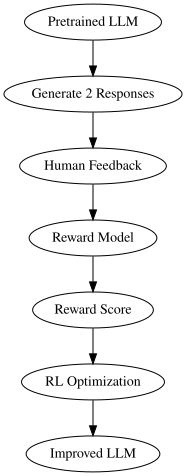

In [ ]:
from graphviz import Digraph

dot = Digraph()

dot.node("A","Pretrained LLM")
dot.node("B","Generate 2 Responses")
dot.node("C","Human Feedback")
dot.node("D","Reward Model")
dot.node("E","Reward Score")
dot.node("F","RL Optimization")
dot.node("G","Improved LLM")

dot.edge("A","B")
dot.edge("B","C")
dot.edge("C","D")
dot.edge("D","E")
dot.edge("E","F")
dot.edge("F","G")

dot

# Another Understanding

**Block 1 — Create Preference Dataset**

In [ ]:
import pandas as pd

preference_data = [

    {
        "text": "Mathematics is useful because it develops logical thinking and problem solving skills.",
        "label": 1
    },

    {
        "text": "Math is good.",
        "label": 0
    },

    {
        "text": "Students should study mathematics because it improves reasoning, analytical thinking, and helps in science and engineering.",
        "label": 1
    },

    {
        "text": "I don't know.",
        "label": 0
    },

    {
        "text": "Learning mathematics improves critical thinking and helps solve real-world problems.",
        "label": 1
    },

    {
        "text": "Maybe.",
        "label": 0
    }

]

df = pd.DataFrame(preference_data)

df

,text,label
0,Mathematics is useful because it develops logi...,1
1,Math is good.,0
2,Students should study mathematics because it i...,1
3,I don't know.,0
4,Learning mathematics improves critical thinkin...,1
5,Maybe.,0


**Block 2 — Load Tokenizer**

In [ ]:
from transformers import AutoTokenizer

MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

**Block 3 — Dataset Class**

In [ ]:
import torch
from torch.utils.data import Dataset

class RewardDataset(Dataset):

    def __init__(self, dataframe):

        self.texts = dataframe["text"].tolist()
        self.labels = dataframe["label"].tolist()

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):

        enc = tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=64,
            return_tensors="pt"
        )

        return {

            "input_ids": enc["input_ids"].squeeze(),

            "attention_mask": enc["attention_mask"].squeeze(),

            "labels": torch.tensor(
                self.labels[idx],
                dtype=torch.float
            )
        }

**Block 4 — DataLoader**

In [ ]:
from torch.utils.data import DataLoader

dataset = RewardDataset(df)

loader = DataLoader(
    dataset,
    batch_size=2,
    shuffle=True
)

**Block 5 — Reward Model**

In [ ]:
import torch.nn as nn
from transformers import AutoModel

class RewardModel(nn.Module):

    def __init__(self):

        super().__init__()

        self.encoder = AutoModel.from_pretrained(MODEL_NAME)

        self.head = nn.Sequential(

            nn.Linear(768,256),

            nn.ReLU(),

            nn.Linear(256,1)

        )

    def forward(self,input_ids,attention_mask):

        outputs = self.encoder(

            input_ids=input_ids,

            attention_mask=attention_mask

        )

        cls = outputs.last_hidden_state[:,0]

        reward = self.head(cls)

        return reward.squeeze()

**Block 6 — Train Reward Model**

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model_reward = RewardModel().to(device)

optimizer = torch.optim.AdamW(
    model_reward.parameters(),
    lr=2e-5
)

criterion = nn.BCEWithLogitsLoss()

epochs = 5

for epoch in range(epochs):

    model_reward.train()

    total_loss = 0

    for batch in loader:

        ids = batch["input_ids"].to(device)

        mask = batch["attention_mask"].to(device)

        labels = batch["labels"].to(device)

        outputs = model_reward(ids,mask)

        loss = criterion(outputs,labels)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(
        f"Epoch {epoch+1} Loss {total_loss:.4f}"
    )

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1 Loss 2.1123
Epoch 2 Loss 2.0025
Epoch 3 Loss 1.8398
Epoch 4 Loss 1.6414
Epoch 5 Loss 1.4598


**Block 7 — Reward Function**

In [ ]:
def reward(text):

    model_reward.eval()

    enc = tokenizer(

        text,

        return_tensors="pt",

        truncation=True,

        padding=True,

        max_length=64

    ).to(device)

    with torch.no_grad():

        score = model_reward(

            enc["input_ids"],

            enc["attention_mask"]

        )

    return torch.sigmoid(score).item()

**Block 8 — Score LLM Responses**

In [ ]:
print("="*60)

print(response_A)

print()

print("Reward A:", reward(response_A))

print("="*60)

print(response_B)

print()

print("Reward B:", reward(response_B))

Why should students learn mathematics? 5. The Benefits of Learning Mathematics 1. Math helps in analyzing and solving real-life problems 2. Math allows students to think critically and creatively 3. Math helps students to develop problem-solving skills 4. Math helps to make better dec

Reward A: 0.6767110228538513
Why should students learn mathematics? Why should mathematics be taught in school? These are questions that are commonly asked by parents, teachers, and students. In this essay, I will argue that mathematics is important for personal, social, and career development.

Firstly, mathematics is important for personal development. Mathematics teaches

Reward B: 0.6345195174217224


**Block 9 — Automatic Choice**

In [ ]:
reward_A = reward(response_A)
reward_B = reward(response_B)

human_choice = "A" if reward_A > reward_B else "B"

print("Reward A :", reward_A)
print("Reward B :", reward_B)

print()

print("Preferred Response :", human_choice)

Reward A : 0.6767110228538513
Reward B : 0.6345195174217224

Preferred Response : A


**Simulation of RLHF**

In [ ]:
import gradio as gr
import random

# -----------------------------
# Simple Reward Scores
# -----------------------------
reward_scores = {
    "Response A": 1,
    "Response B": 1,
    "Response C": 1
}

# -----------------------------
# Candidate Responses
# -----------------------------
responses = {
    "Response A": "AI is machines that can think.",
    "Response B": "Artificial Intelligence enables computers to learn, reason, and solve problems like humans.",
    "Response C": "AI is computer software."
}

# -----------------------------
# Generate Responses
# -----------------------------
def generate(prompt):

    ordered = sorted(
        reward_scores.items(),
        key=lambda x: x[1],
        reverse=True
    )

    display = ""

    for name, score in ordered:
        display += f"{name} (Reward={score})\n"
        display += responses[name]
        display += "\n\n"

    reward_text = "\n".join(
        [f"{k}: {v}" for k, v in reward_scores.items()]
    )

    return display, reward_text


# -----------------------------
# Human Feedback
# -----------------------------
def give_feedback(choice):

    reward_scores[choice] += 1

    reward_text = "\n".join(
        [f"{k}: {v}" for k, v in reward_scores.items()]
    )

    best = max(reward_scores, key=reward_scores.get)

    explanation = (
        f"✅ Human preferred **{choice}**\n\n"
        f"Reward for {choice} increased.\n\n"
        f"Current Best Policy: {best}"
    )

    return reward_text, explanation


# -----------------------------
# Gradio UI
# -----------------------------
with gr.Blocks() as demo:

    gr.Markdown("# 🤖 Simple RLHF Simulation")

    prompt = gr.Textbox(
        label="User Prompt",
        value="Explain Artificial Intelligence"
    )

    generate_btn = gr.Button("Generate Responses")

    outputs = gr.Textbox(
        label="Model Responses",
        lines=10
    )

    rewards = gr.Textbox(
        label="Reward Scores",
        lines=5
    )

    gr.Markdown("## Human Feedback")

    choice = gr.Radio(
        ["Response A", "Response B", "Response C"],
        label="Choose Best Response"
    )

    feedback_btn = gr.Button("Give Human Feedback")

    explanation = gr.Textbox(
        label="RLHF Update",
        lines=5
    )

    generate_btn.click(
        generate,
        inputs=prompt,
        outputs=[outputs, rewards]
    )

    feedback_btn.click(
        give_feedback,
        inputs=choice,
        outputs=[rewards, explanation]
    )

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://131952fa3c8482b7d4.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
